

###  Exploratory Data Analysis (EDA)

**Exploring Shopsy kitchen product data to understand pricing, discounts, ratings, reviews, materials, and capacities.**

**Workflow:** Load Data → Inspect Data → Descriptive Statistics → Analyze Distributions → Explore Relationships → Identify Patterns → Generate Insights

</div>



### Libraries

**Python libraries used for exploratory data analysis and visualization.**



</div>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [8]:
df = pd.read_csv("shopsy_kitchen_products.csv")



###   Dataset Overview

**Inspecting the dataset structure, data types, statistics, missing values, duplicates, and unique values.**

</div>

In [9]:
print("Dataset loaded successfully!")
print("=" * 60)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nDataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nDataset Information:")
df.info()
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nMissing Value Percentage:")
print((df.isnull().sum() / len(df)) * 100)
print("\nDuplicate Rows:")
print(df.duplicated().sum())
print("\nUnique Values:")
for column in df.columns:
    print(column, ":", df[column].nunique())

Dataset loaded successfully!

First 5 rows:
                                        Product_Name Price Discount  Rating  \
0  Qtrix Pack of 8 Plastic Grocery Container - 50...  ₹300      69%     4.4   
1  AneriDEALS Pack of 24 Plastic Grocery Containe...  ₹423      78%     4.1   
2  BELIZZI Pack of 6 Plastic Fridge Container - 1...  ₹257      74%     4.1   
3   SHAN Pack of 2 Ceramic Pickle Jar - 500 ml Green  ₹345      50%     4.3   
4  RK Pack of 5 Steel Cookie Jar - 300 ml, 500 ml...  ₹383      76%     4.1   

   Reviews   Brand                                           Capacity  \
0    104.0  Shopsy                           500 ml, 1100 ml, 1500 ml   
1     34.0  Shopsy           250 ml, 350 ml, 650 ml, 1200 ml, 1000 ml   
2    272.0  Shopsy                           1500 ml, 500 ml, 1000 ml   
3      NaN  Shopsy                                             500 ml   
4     83.0  Shopsy  300 ml, 500 ml, 750 ml, 1150 ml, 1650 ml, 375 ...   

  Material                                



###   Univariate Analysis

**Analyzing the individual distributions of price, discount, rating, and reviews.**

</div>

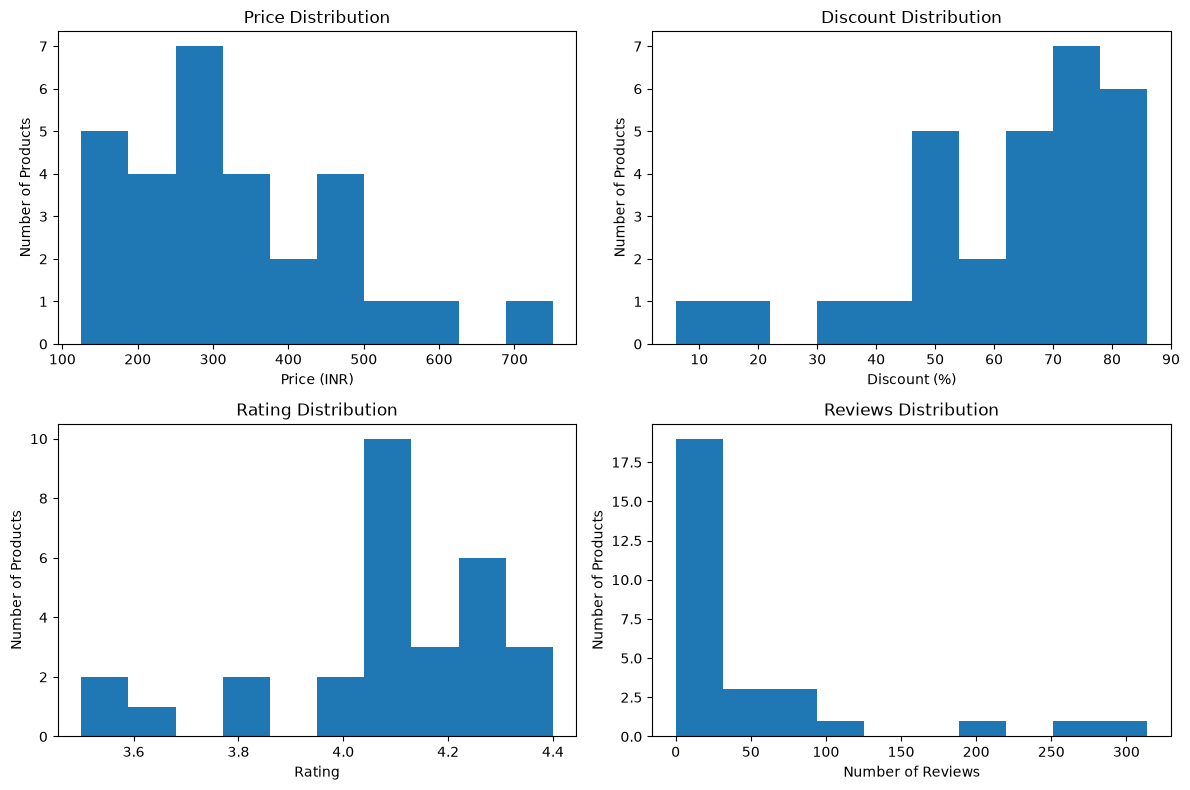

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["Price_INR"].dropna(), bins=10)
axes[0, 0].set_title("Price Distribution")
axes[0, 0].set_xlabel("Price (INR)")
axes[0, 0].set_ylabel("Number of Products")

axes[0, 1].hist(df["Discount_Pct"].dropna(), bins=10)
axes[0, 1].set_title("Discount Distribution")
axes[0, 1].set_xlabel("Discount (%)")
axes[0, 1].set_ylabel("Number of Products")

axes[1, 0].hist(df["Rating"].dropna(), bins=10)
axes[1, 0].set_title("Rating Distribution")
axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("Number of Products")

axes[1, 1].hist(df["Reviews"].dropna(), bins=10)
axes[1, 1].set_title("Reviews Distribution")
axes[1, 1].set_xlabel("Number of Reviews")
axes[1, 1].set_ylabel("Number of Products")

plt.tight_layout()
plt.show()


###   Categorical & Bivariate Analysis

**Analyzing product categories and exploring relationships between price, discount, rating, and reviews.**

</div>

Material Distribution:
Material
Plastic                            20
Steel                               3
Stainless Steel, Steel              2
Ceramic                             1
Plastic, Steel                      1
Glass                               1
Stainless Steel, Plastic, Steel     1
Name: count, dtype: int64

Capacity Distribution:
Capacity
1200 ml                                                                               3
2500 ml                                                                               3
500 ml, 1100 ml, 1500 ml                                                              1
250 ml, 350 ml, 650 ml, 1200 ml, 1000 ml                                              1
1500 ml, 500 ml, 1000 ml                                                              1
500 ml                                                                                1
300 ml, 500 ml, 750 ml, 1150 ml, 1650 ml, 375 ml, 625 ml, 1000 ml, 1375 ml, 250 ml    1
4500 ml, 250 ml            

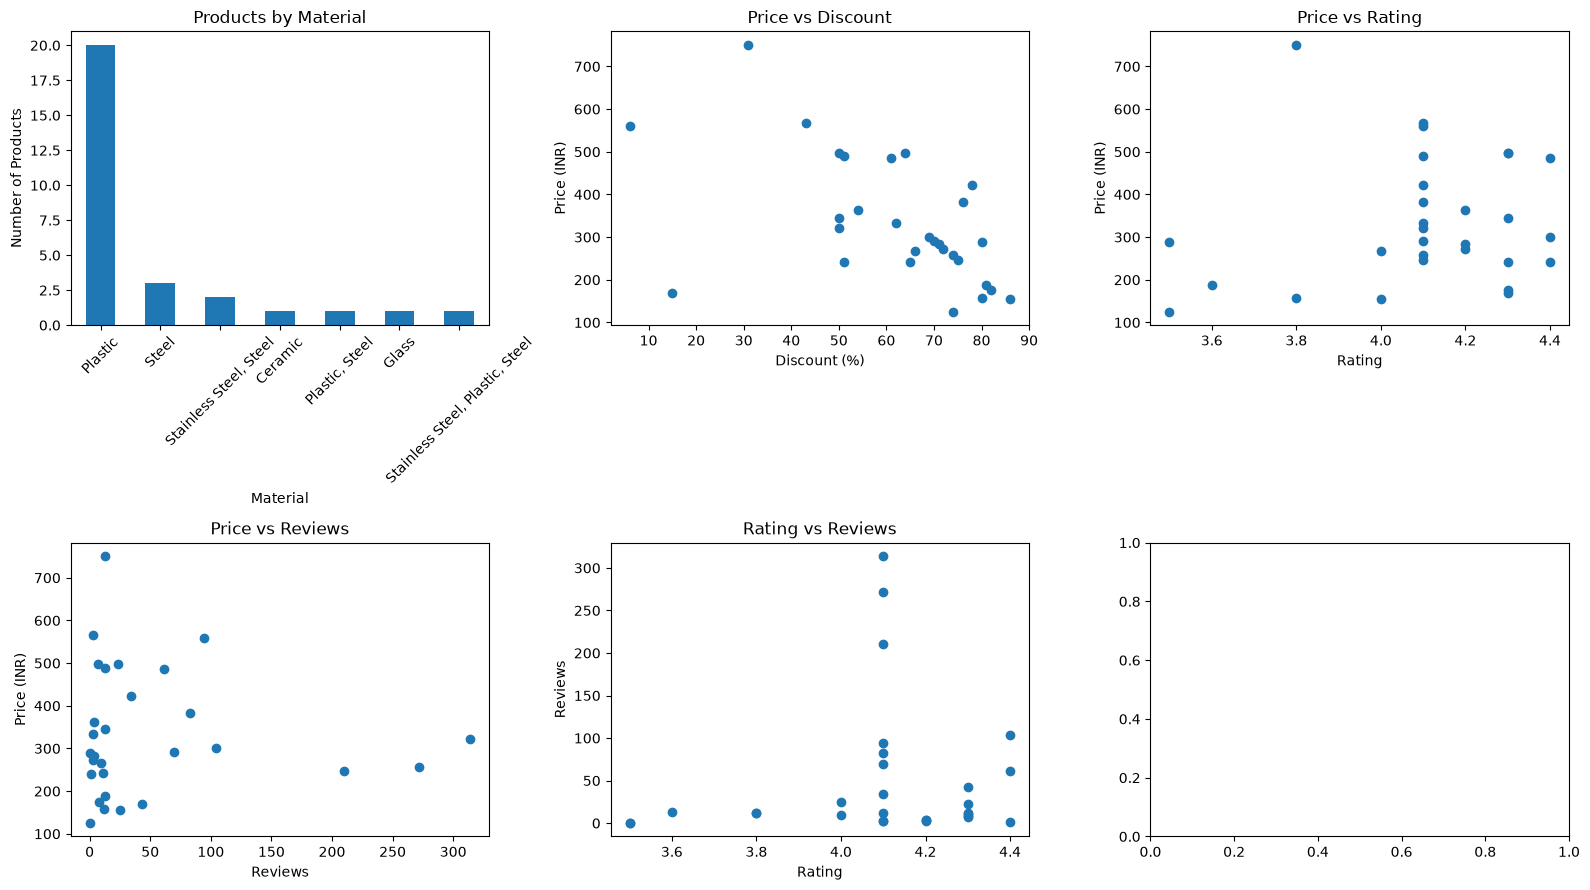

In [4]:
print("Material Distribution:")
print(df["Material"].value_counts())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
df["Material"].value_counts().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Products by Material")
axes[0, 0].set_xlabel("Material")
axes[0, 0].set_ylabel("Number of Products")
axes[0, 0].tick_params(axis="x", rotation=45)

print("\nCapacity Distribution:")
print(df["Capacity"].value_counts().head(15))

plots = [("Discount_Pct", "Price_INR", "Price vs Discount", "Discount (%)", "Price (INR)"),
         ("Rating", "Price_INR", "Price vs Rating", "Rating", "Price (INR)"),
         ("Reviews", "Price_INR", "Price vs Reviews", "Reviews", "Price (INR)"),
         ("Rating", "Reviews", "Rating vs Reviews", "Rating", "Reviews")]
for axis, (x_column, y_column, title, x_label, y_label) in zip(axes.flat[1:], plots):
    axis.scatter(df[x_column], df[y_column])
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)

plt.tight_layout()
plt.show()


### Grouped Analysis & Top Products

**Comparing product performance across brands and identifying top products based on ratings, reviews, price, and discounts.**

</div>

In [5]:
avg_price_material = df.groupby("Material")["Price_INR"].mean().sort_values(ascending=False)
avg_rating_material = df.groupby("Material")["Rating"].mean().sort_values(ascending=False)
avg_discount_material = df.groupby("Material")["Discount_Pct"].mean().sort_values(ascending=False)

print("Average Price by Material:")
print(avg_price_material)
print("\nAverage Rating by Material:")
print(avg_rating_material)
print("\nAverage Discount by Material:")
print(avg_discount_material)

top_reviews = df.sort_values("Reviews", ascending=False).head(10)
top_rated = df.sort_values(["Rating", "Reviews"], ascending=[False, False]).head(10)

print("\nTop 10 Most Reviewed Products:")
print(top_reviews[["Product_Name", "Price_INR", "Discount_Pct", "Rating", "Reviews"]])
print("\nTop 10 Rated Products:")
print(top_rated[["Product_Name", "Price_INR", "Rating", "Reviews"]])

Average Price by Material:
Material
Plastic, Steel                     567.0
Steel                              489.0
Ceramic                            345.0
Plastic                            319.1
Stainless Steel, Plastic, Steel    292.0
Stainless Steel, Steel             227.5
Glass                              169.0
Name: Price_INR, dtype: float64

Average Rating by Material:
Material
Ceramic                            4.30
Glass                              4.30
Plastic                            4.12
Plastic, Steel                     4.10
Stainless Steel, Plastic, Steel    4.10
Steel                              4.00
Stainless Steel, Steel             3.80
Name: Rating, dtype: float64

Average Discount by Material:
Material
Stainless Steel, Steel             73.500000
Stainless Steel, Plastic, Steel    70.000000
Plastic                            64.650000
Steel                              56.333333
Ceramic                            50.000000
Plastic, Steel                   



###  5. Correlation, Outliers & Business Questions

**Analyzing relationships between numerical variables, identifying unusual values, and answering key business questions.**

</div>

Correlation Matrix:
              Price_INR  Discount_Pct    Rating   Reviews
Price_INR      1.000000     -0.541056  0.156719 -0.051366
Discount_Pct  -0.541056      1.000000 -0.257075 -0.026447
Rating         0.156719     -0.257075  1.000000  0.105933
Reviews       -0.051366     -0.026447  0.105933  1.000000


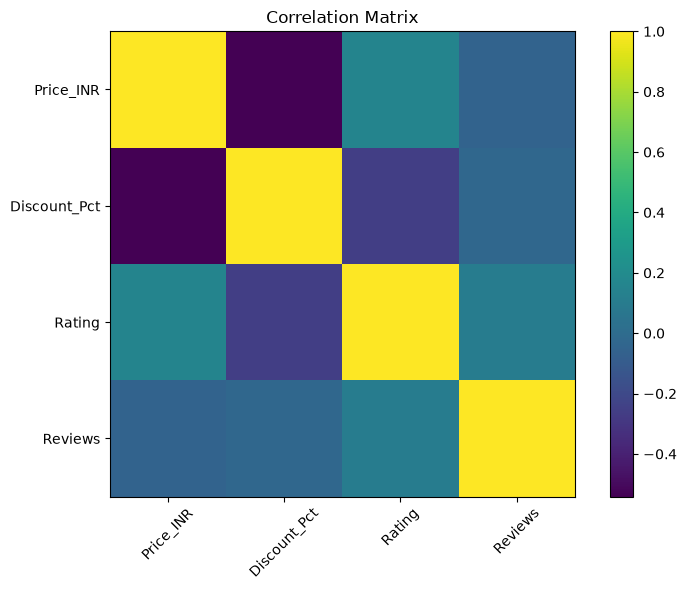

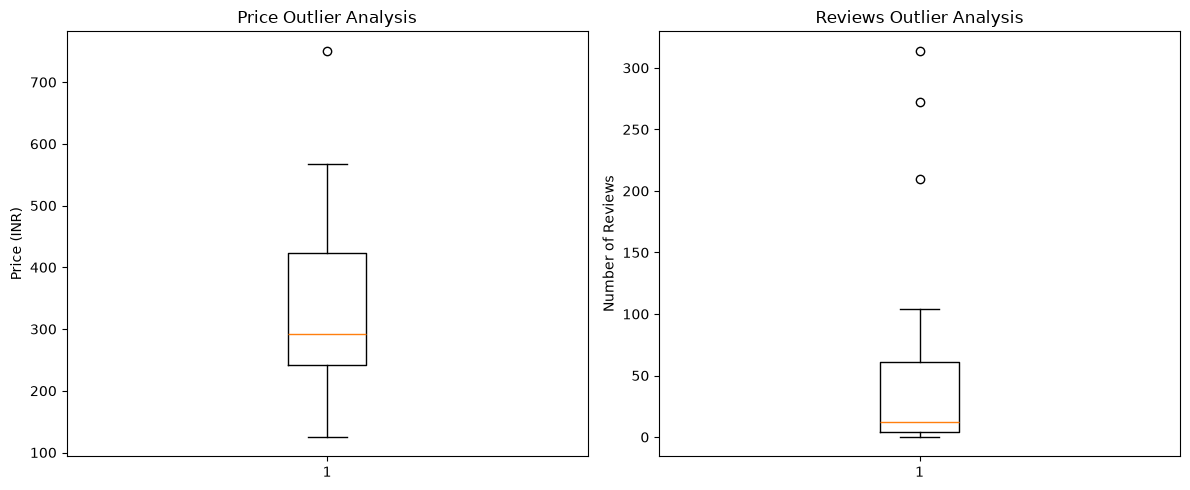

Cheapest Product: TASTIC Pack of 1 Plastic Grocery Container - 1800 ml Black | Price: 125
Most Expensive Product: Kitcorner Pack of 8 Steel Utility Container - 350 ml Red | Price: 751
Highest Discount Product: VASOYA Pack of 1 Plastic Fridge Container - 2700 ml White | Discount: 86 %
Most Reviewed Product: koktailkitchan Pack of 12 Plastic Grocery Container - 500 ml Black | Reviews: 314.0
Highest Rated Product: Qtrix Pack of 8 Plastic Grocery Container - 500 ml, 1100 ml Black | Rating: 4.4

Final Dataset Shape:
(29, 11)
Final Columns:
['Product_Name', 'Price', 'Discount', 'Rating', 'Reviews', 'Brand', 'Capacity', 'Material', 'Product_URL', 'Price_INR', 'Discount_Pct']
EDA COMPLETED SUCCESSFULLY!


In [6]:
numeric_columns = ["Price_INR", "Discount_Pct", "Rating", "Reviews"]
correlation = df[numeric_columns].corr()
print("Correlation Matrix:")
print(correlation)

plt.figure(figsize=(8, 6))
plt.imshow(correlation, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(df["Price_INR"].dropna())
axes[0].set_title("Price Outlier Analysis")
axes[0].set_ylabel("Price (INR)")
axes[1].boxplot(df["Reviews"].dropna())
axes[1].set_title("Reviews Outlier Analysis")
axes[1].set_ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

cheapest = df.loc[df["Price_INR"].idxmin()]
expensive = df.loc[df["Price_INR"].idxmax()]
highest_discount = df.loc[df["Discount_Pct"].idxmax()]
most_reviewed = df.loc[df["Reviews"].idxmax()]
highest_rated = df.loc[df["Rating"].idxmax()]

print("Cheapest Product:", cheapest["Product_Name"], "| Price:", cheapest["Price_INR"])
print("Most Expensive Product:", expensive["Product_Name"], "| Price:", expensive["Price_INR"])
print("Highest Discount Product:", highest_discount["Product_Name"], "| Discount:", highest_discount["Discount_Pct"], "%")
print("Most Reviewed Product:", most_reviewed["Product_Name"], "| Reviews:", most_reviewed["Reviews"])
print("Highest Rated Product:", highest_rated["Product_Name"], "| Rating:", highest_rated["Rating"])

print("\nFinal Dataset Shape:")
print(df.shape)
print("Final Columns:")
print(df.columns.tolist())
print("EDA COMPLETED SUCCESSFULLY!")



### EDA & Business Insights — Conclusion

</div>

**Key Findings**

- Identified pricing patterns and common price ranges.
- Compared discount levels across products and brands.
- Analyzed rating distribution to understand customer satisfaction.
- Identified products and brands with high customer review activity.
- Compared product availability across different materials.
- Analyzed product distribution across capacity categories.
- Examined relationships between price, discount, ratings, and reviews.
- Identified potential outliers in price, discount, and review counts.
- Highlighted top-rated and highly reviewed products.
- Compared brand-level performance using grouped analysis.
- Generated actionable insights for product and pricing decisions.
- Transformed raw product data into meaningful business insights.